In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import joblib
X, y = joblib.load("features_cache.pkl")

In [3]:
models = ['Random Forest', 'XGBoost', 'CNN']

mae    = [12.06, 12.04, 9.91]
mae_std= [0.83,  0.80,  0.74]
acc1   = [0.426, 0.411, 0.408]
acc1_std=[0.039, 0.033, 0.065]
acc2   = [0.438, 0.422, 0.432]
acc2_std=[0.040, 0.036, 0.054]

cnn_loss = {
    'Fold 1': [21.720, 20.229, 19.646, 18.993],
    'Fold 2': [22.727, 21.533, 20.959, 20.379],
    'Fold 3': [21.013, 19.678, 19.472, 18.686],
    'Fold 4': [23.491, 20.678, 20.486, 19.818],
    'Fold 5': [23.189, 20.753, 21.443, 20.868],
}
epochs = [20, 40, 60, 80]

colors = ['#4878CF', '#6ACC65', '#D65F5F']

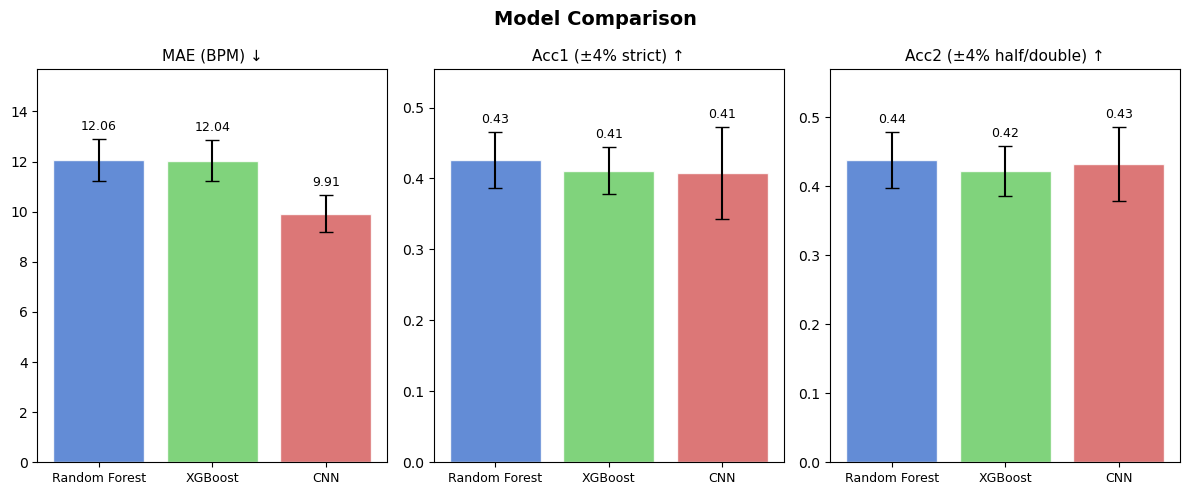

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(12, 5))
fig.suptitle('Model Comparison', fontsize=14, fontweight='bold')

metrics     = [mae,  acc1,  acc2]
stds        = [mae_std, acc1_std, acc2_std]
titles      = ['MAE (BPM) ↓', 'Acc1 (±4% strict) ↑', 'Acc2 (±4% half/double) ↑']

for ax, vals, stds_, title in zip(axes, metrics, stds, titles):
    bars = ax.bar(models, vals, yerr=stds_, capsize=5, color=colors, alpha=0.85, edgecolor='white')
    ax.set_title(title, fontsize=11)
    ax.set_ylim(0, max(vals) * 1.3)
    ax.tick_params(axis='x', labelsize=9)
    for bar, val, std in zip(bars, vals, stds_):
        ax.text(bar.get_x() + bar.get_width()/2, val + std + max(vals)*0.02,
                f'{val:.2f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

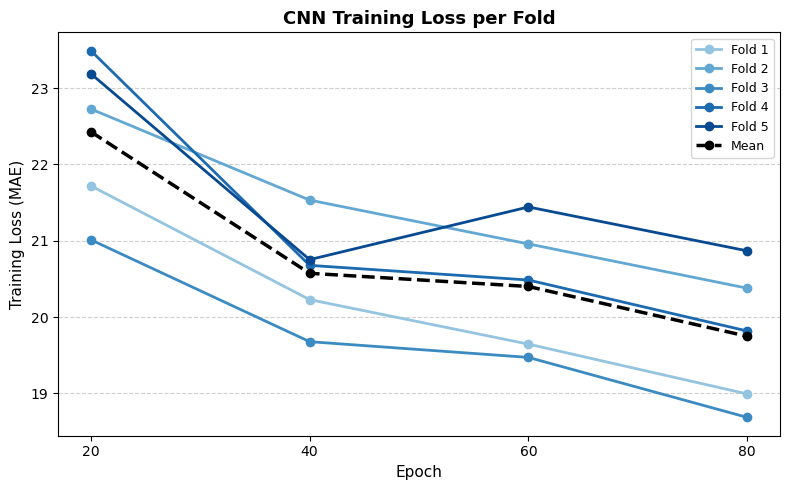

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
fold_colors = plt.cm.Blues(np.linspace(0.4, 0.9, 5))

for (fold_name, losses), c in zip(cnn_loss.items(), fold_colors):
    ax.plot(epochs, losses, marker='o', label=fold_name, color=c, linewidth=2)

mean_losses = np.mean(list(cnn_loss.values()), axis=0)
ax.plot(epochs, mean_losses, marker='o', label='Mean', color='black',
        linewidth=2.5, linestyle='--')

ax.set_xlabel('Epoch', fontsize=11)
ax.set_ylabel('Training Loss (MAE)', fontsize=11)
ax.set_title('CNN Training Loss per Fold', fontsize=13, fontweight='bold')
ax.set_xticks(epochs)
ax.legend(fontsize=9)
ax.yaxis.grid(True, linestyle='--', alpha=0.6)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('cnn_loss_curve.png', dpi=150, bbox_inches='tight')
plt.show()


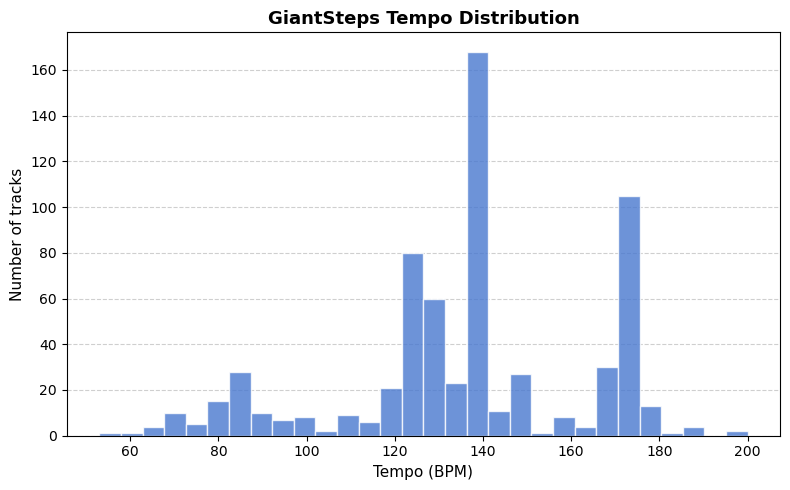

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(y, bins=30, color='#4878CF', alpha=0.8, edgecolor='white')
ax.set_xlabel('Tempo (BPM)', fontsize=11)
ax.set_ylabel('Number of tracks', fontsize=11)
ax.set_title('GiantSteps Tempo Distribution', fontsize=13, fontweight='bold')
ax.yaxis.grid(True, linestyle='--', alpha=0.6)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('bpm_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

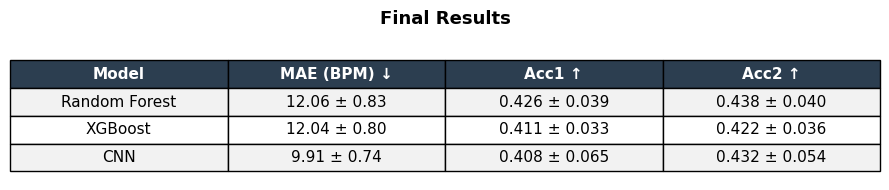

In [7]:
fig, ax = plt.subplots(figsize=(9, 2))
ax.axis('off')

table_data = [
    ['Random Forest', '12.06 ± 0.83', '0.426 ± 0.039', '0.438 ± 0.040'],
    ['XGBoost',       '12.04 ± 0.80', '0.411 ± 0.033', '0.422 ± 0.036'],
    ['CNN',           '9.91 ± 0.74',  '0.408 ± 0.065', '0.432 ± 0.054'],
]

col_labels = ['Model', 'MAE (BPM) ↓', 'Acc1 ↑', 'Acc2 ↑']

table = ax.table(
    cellText=table_data,
    colLabels=col_labels,
    loc='center',
    cellLoc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 2)

for j in range(len(col_labels)):
    table[0, j].set_facecolor('#2c3e50')
    table[0, j].set_text_props(color='white', fontweight='bold')


row_colors = ['#f2f2f2', '#ffffff', '#f2f2f2']
for i, color in enumerate(row_colors, start=1):
    for j in range(len(col_labels)):
        table[i, j].set_facecolor(color)


# for j in range(len(col_labels)):
#     table[3, j].set_facecolor('#d4edda')
#     table[3, j].set_text_props(fontweight='bold')

ax.set_title('Final Results', fontsize=13, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('results_table.png', dpi=150, bbox_inches='tight')
plt.show()

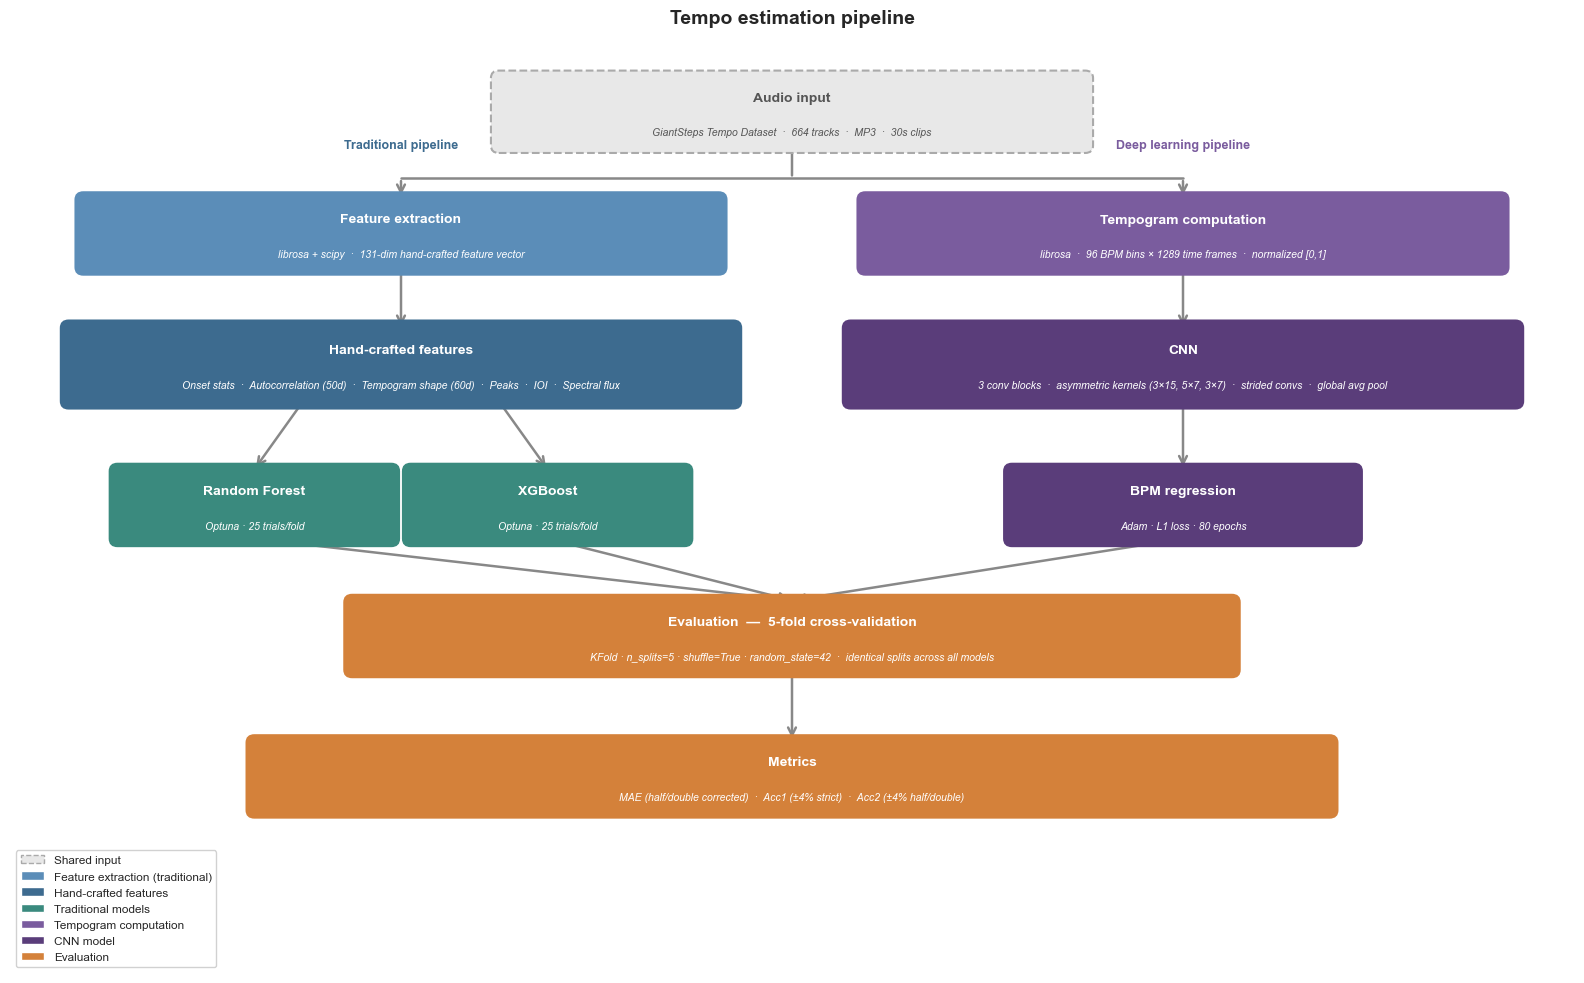

In [8]:
sns.set_theme(style="white")

fig, ax = plt.subplots(figsize=(16, 10))
ax.set_xlim(0, 16)
ax.set_ylim(0, 10)
ax.axis('off')

def draw_box(ax, x, y, w, h, label, sublabel=None,
             facecolor='#5b8db8', textcolor='white',
             edgecolor=None, alpha=1.0, fontsize=10,
             linestyle='solid'):
    if edgecolor is None:
        edgecolor = facecolor
    rect = mpatches.FancyBboxPatch((x - w/2, y - h/2), w, h,
                                    boxstyle="round,pad=0.08",
                                    facecolor=facecolor,
                                    edgecolor=edgecolor,
                                    linewidth=1.5,
                                    alpha=alpha,
                                    linestyle=linestyle,
                                    zorder=2)
    ax.add_patch(rect)
    if sublabel:
        ax.text(x, y + 0.15, label, ha='center', va='center',
                fontsize=fontsize, fontweight='bold',
                color=textcolor, alpha=alpha, zorder=3)
        ax.text(x, y - 0.22, sublabel, ha='center', va='center',
                fontsize=7.5, color=textcolor, alpha=alpha, zorder=3,
                style='italic')
    else:
        ax.text(x, y, label, ha='center', va='center',
                fontsize=fontsize, fontweight='bold',
                color=textcolor, alpha=alpha, zorder=3)

def arrow(ax, x1, y1, x2, y2, color='#888888'):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color=color, lw=1.8, mutation_scale=14), zorder=1)

def split_arrow(ax, x_start, y_start, x_end1, y_end1, x_end2, y_end2, color='#888888'):
    mid_y = y_start - 0.35
    ax.annotate('', xy=(x_start, mid_y), xytext=(x_start, y_start),
                arrowprops=dict(arrowstyle='-', color=color, lw=1.8), zorder=1)
    ax.plot([x_end1, x_end2], [mid_y, mid_y], color=color, lw=1.8, zorder=1)
    arrow(ax, x_end1, mid_y, x_end1, y_end1, color)
    arrow(ax, x_end2, mid_y, x_end2, y_end2, color)

blue       = '#5b8db8'
blue_dark  = '#3d6b8f'
teal       = '#3a8a7e'
purple     = '#7a5c9e'
orange     = '#d4813a'
grey_face  = '#e8e8e8'
grey_edge  = '#aaaaaa'
grey_text  = '#555555'

y_audio  = 9.2
y_split  = 7.9
y_feat   = 6.5
y_model  = 5.0
y_eval   = 3.6
y_metric = 2.1

draw_box(ax, 8, y_audio, 6.0, 0.72,
         'Audio input',
         sublabel='GiantSteps Tempo Dataset  ·  664 tracks  ·  MP3  ·  30s clips',
         facecolor=grey_face, edgecolor=grey_edge, textcolor=grey_text,
         linestyle='dashed', fontsize=10)

split_arrow(ax, 8, y_audio - 0.36, 4.0, y_split + 0.38, 12.0, y_split + 0.38)

ax.text(4.0, y_split + 0.95, 'Traditional pipeline', ha='center', va='center',
        fontsize=9, color=blue_dark, fontweight='bold')
ax.text(12.0, y_split + 0.95, 'Deep learning pipeline', ha='center', va='center',
        fontsize=9, color=purple, fontweight='bold')

draw_box(ax, 4.0, y_split, 6.5, 0.72,
         'Feature extraction',
         sublabel='librosa + scipy  ·  131-dim hand-crafted feature vector',
         facecolor=blue, textcolor='white', fontsize=10)

draw_box(ax, 12.0, y_split, 6.5, 0.72,
         'Tempogram computation',
         sublabel='librosa  ·  96 BPM bins × 1289 time frames  ·  normalized [0,1]',
         facecolor=purple, textcolor='white', fontsize=10)

arrow(ax, 4.0, y_split - 0.36, 4.0, y_feat + 0.38)
arrow(ax, 12.0, y_split - 0.36, 12.0, y_feat + 0.38)

draw_box(ax, 4.0, y_feat, 6.8, 0.78,
         'Hand-crafted features',
         sublabel='Onset stats  ·  Autocorrelation (50d)  ·  Tempogram shape (60d)  ·  Peaks  ·  IOI  ·  Spectral flux',
         facecolor=blue_dark, textcolor='white', fontsize=10)

draw_box(ax, 12.0, y_feat, 6.8, 0.78,
         'CNN',
         sublabel='3 conv blocks  ·  asymmetric kernels (3×15, 5×7, 3×7)  ·  strided convs  ·  global avg pool',
         facecolor='#5a3d7a', textcolor='white', fontsize=10)

arrow(ax, 3.0, y_feat - 0.39, 2.5, y_model + 0.38)
arrow(ax, 5.0, y_feat - 0.39, 5.5, y_model + 0.38)
arrow(ax, 12.0, y_feat - 0.39, 12.0, y_model + 0.38)

draw_box(ax, 2.5, y_model, 2.8, 0.72,
         'Random Forest',
         sublabel='Optuna · 25 trials/fold',
         facecolor=teal, textcolor='white', fontsize=10)

draw_box(ax, 5.5, y_model, 2.8, 0.72,
         'XGBoost',
         sublabel='Optuna · 25 trials/fold',
         facecolor=teal, textcolor='white', fontsize=10)

draw_box(ax, 12.0, y_model, 3.5, 0.72,
         'BPM regression',
         sublabel='Adam · L1 loss · 80 epochs',
         facecolor='#5a3d7a', textcolor='white', fontsize=10)

for x in [2.5, 5.5, 12.0]:
    arrow(ax, x, y_model - 0.36, 8.0, y_eval + 0.38)

draw_box(ax, 8.0, y_eval, 9.0, 0.72,
         'Evaluation  —  5-fold cross-validation',
         sublabel='KFold · n_splits=5 · shuffle=True · random_state=42  ·  identical splits across all models',
         facecolor=orange, textcolor='white', fontsize=10)

arrow(ax, 8.0, y_eval - 0.36, 8.0, y_metric + 0.38)

draw_box(ax, 8.0, y_metric, 11.0, 0.72,
         'Metrics',
         sublabel='MAE (half/double corrected)  ·  Acc1 (±4% strict)  ·  Acc2 (±4% half/double)',
         facecolor=orange, textcolor='white', fontsize=10)

legend_elements = [
    mpatches.Patch(facecolor=grey_face, edgecolor=grey_edge, linestyle='dashed', label='Shared input'),
    mpatches.Patch(facecolor=blue, label='Feature extraction (traditional)'),
    mpatches.Patch(facecolor=blue_dark, label='Hand-crafted features'),
    mpatches.Patch(facecolor=teal, label='Traditional models'),
    mpatches.Patch(facecolor=purple, label='Tempogram computation'),
    mpatches.Patch(facecolor='#5a3d7a', label='CNN model'),
    mpatches.Patch(facecolor=orange, label='Evaluation'),
]
ax.legend(handles=legend_elements, loc='lower left', fontsize=8.5,
          frameon=True, framealpha=0.9, edgecolor='#cccccc',
          bbox_to_anchor=(0.0, 0.0))

ax.set_title('Tempo estimation pipeline', fontsize=14, fontweight='bold', pad=10)

plt.tight_layout()
plt.savefig('pipeline_flowchart.png', dpi=300, bbox_inches='tight')
plt.show()

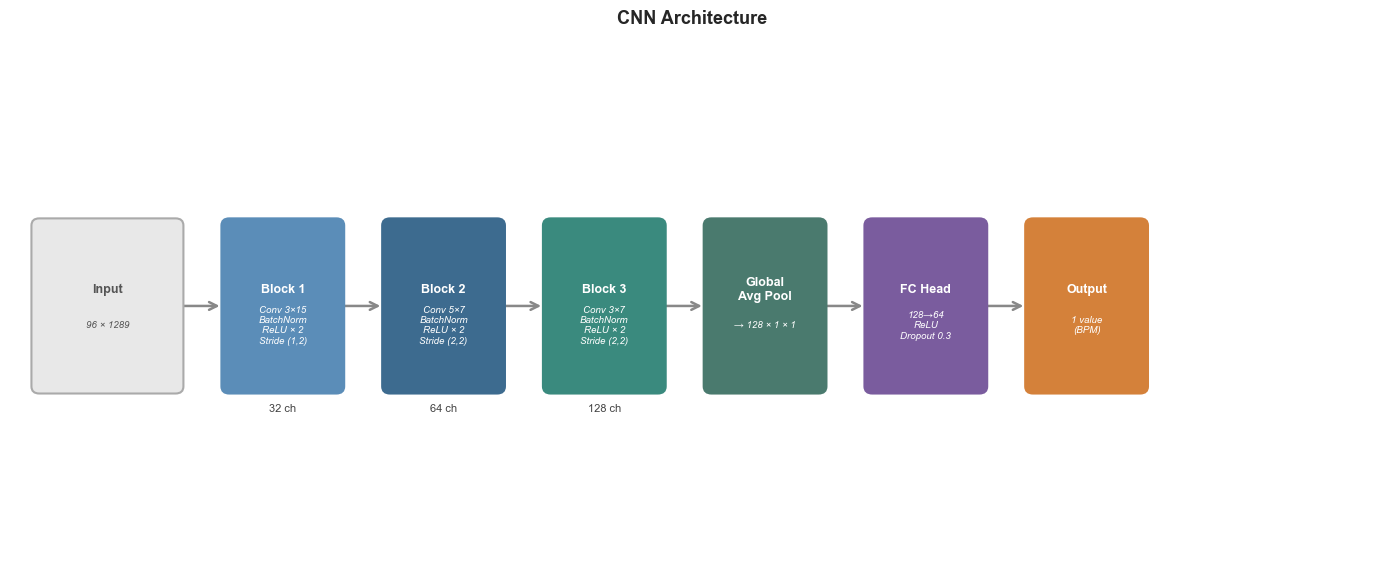

In [9]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.set_xlim(0, 14)
ax.set_ylim(0, 6)
ax.axis('off')

def draw_box(ax, x, y, w, h, label, sublabel=None,
             facecolor='#5b8db8', textcolor='white',
             edgecolor=None, fontsize=9):
    if edgecolor is None:
        edgecolor = facecolor
    rect = mpatches.FancyBboxPatch((x - w/2, y - h/2), w, h,
                                    boxstyle="round,pad=0.08",
                                    facecolor=facecolor,
                                    edgecolor=edgecolor,
                                    linewidth=1.5,
                                    zorder=2)
    ax.add_patch(rect)
    if sublabel:
        ax.text(x, y + 0.18, label, ha='center', va='center',
                fontsize=fontsize, fontweight='bold',
                color=textcolor, zorder=3)
        ax.text(x, y - 0.22, sublabel, ha='center', va='center',
                fontsize=7, color=textcolor, zorder=3, style='italic')
    else:
        ax.text(x, y, label, ha='center', va='center',
                fontsize=fontsize, fontweight='bold',
                color=textcolor, zorder=3)

def arrow(ax, x1, x2, y=3.0, color='#888888'):
    ax.annotate('', xy=(x2, y), xytext=(x1, y),
                arrowprops=dict(arrowstyle='->', color=color, lw=1.8, mutation_scale=14), zorder=1)

grey_face  = '#e8e8e8'
grey_edge  = '#aaaaaa'
grey_text  = '#555555'
blue       = '#5b8db8'
blue_dark  = '#3d6b8f'
teal       = '#3a8a7e'
purple     = '#7a5c9e'
orange     = '#d4813a'

y = 3.0

# Input
draw_box(ax, 1.0, y, 1.4, 1.8,
         'Input',
         sublabel='96 × 1289',
         facecolor=grey_face, edgecolor=grey_edge, textcolor=grey_text)

arrow(ax, 1.72, 2.18)

# Block 1
draw_box(ax, 2.8, y, 1.1, 1.8,
         'Block 1',
         sublabel='Conv 3×15\nBatchNorm\nReLU × 2\nStride (1,2)',
         facecolor=blue)

arrow(ax, 3.37, 3.83)

# Block 2
draw_box(ax, 4.45, y, 1.1, 1.8,
         'Block 2',
         sublabel='Conv 5×7\nBatchNorm\nReLU × 2\nStride (2,2)',
         facecolor=blue_dark)

arrow(ax, 5.02, 5.48)

# Block 3
draw_box(ax, 6.1, y, 1.1, 1.8,
         'Block 3',
         sublabel='Conv 3×7\nBatchNorm\nReLU × 2\nStride (2,2)',
         facecolor=teal)

arrow(ax, 6.67, 7.13)

# Global Avg Pool
draw_box(ax, 7.75, y, 1.1, 1.8,
         'Global\nAvg Pool',
         sublabel='→ 128 × 1 × 1',
         facecolor='#4a7a6e')

arrow(ax, 8.32, 8.78)

# Flatten + FC
draw_box(ax, 9.4, y, 1.1, 1.8,
         'FC Head',
         sublabel='128→64\nReLU\nDropout 0.3',
         facecolor=purple)

arrow(ax, 9.97, 10.43)

# Output
draw_box(ax, 11.05, y, 1.1, 1.8,
         'Output',
         sublabel='1 value\n(BPM)',
         facecolor=orange)

# Channel labels below boxes
for x, label in zip([2.8, 4.45, 6.1], ['32 ch', '64 ch', '128 ch']):
    ax.text(x, y - 1.15, label, ha='center', va='center',
            fontsize=8, color='#444444')

ax.set_title('CNN Architecture', fontsize=13, fontweight='bold', pad=10)

plt.tight_layout()
plt.savefig('cnn_architecture.png', dpi=300, bbox_inches='tight')
plt.show()